# Multi-Factor Long-Short Strategy — NL / FR / BE

**Goal:** Build a multi-factor composite score, go long top quintile and short bottom quintile, inverse-vol weighted. Evaluate by CAPM Information Ratio (net of TC).

**Candidate signals:**
- Value (BEME) — high = cheap = long
- Quality (OP) — high = profitable = long
- Conservative Investment (−INV) — low growth = long
- Low Risk (−β) — low beta = long
- Momentum (RET11) — high past return = long

Value and Quality are always included (base signals). The rest go through 5-fold CV to pick the best subset. Momentum capped to avoid being classified as a pure momentum strategy.


In [77]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
import itertools

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# --- Parameters ---
DATA_DIR = './'
TC_BPS = 30              # one-way transaction cost in bps
N_QUANTILES = 5
LONG_Q = N_QUANTILES     # top quintile = long
SHORT_Q = 1              # bottom quintile = short
MIN_STOCKS_PER_LEG = 20
WINSOR_LIMITS = (0.01, 0.99)

# Prior signal weights (before model selection)
FULL_SIGNAL_WEIGHTS = {
    'value': 0.25,
    'quality': 0.20,
    'investment': 0.15,
    'low_risk': 0.20,
    'momentum': 0.20,
}

def get_rescaled_weights(selected_signals, FULL_SIGNAL_WEIGHTS=FULL_SIGNAL_WEIGHTS, as_percent=False):
    """Rescale weights proportionally so they sum to 1 after dropping signals."""
    filtered = {s: FULL_SIGNAL_WEIGHTS[s] for s in selected_signals}
    total = sum(filtered.values())
    if as_percent:
        return {s: (w / total) * 100 for s, w in filtered.items()}
    else:
        return {s: w / total for s, w in filtered.items()}


In [78]:
# Load the four datasets
monthly = pd.read_csv(f'{DATA_DIR}NL_FR_BE_data_monthly.csv')
annual  = pd.read_csv(f'{DATA_DIR}NL_FR_BE_data_annual.csv')
firms   = pd.read_csv(f'{DATA_DIR}NL_FR_BE_firms.csv')
factors = pd.read_csv(f'{DATA_DIR}Europe_FF_Factors.csv')

print(f"Monthly: {monthly.shape[0]:,} rows, {monthly['ISIN'].nunique()} firms, {monthly['mdate'].min()}–{monthly['mdate'].max()}")
print(f"Annual:  {annual.shape[0]:,} rows, {annual['ISIN'].nunique()} firms")
print(f"Factors: {factors.shape[0]} months")
print(f"Firms:   {firms.shape[0]} | {firms['country'].value_counts().to_dict()}")


Monthly: 254,523 rows, 1905 firms, 199106–202205
Annual:  23,126 rows, 1905 firms
Factors: 373 months
Firms:   1905 | {'FR': 1440, 'NL': 250, 'BE': 215}


In [79]:
# Data preparation
monthly['year']  = monthly['mdate'] // 100
monthly['month'] = monthly['mdate'] % 100

# Fama-French lag: fiscal year t data available from July t+1
# month >= 7 -> use fyear = year-1, month < 7 -> use fyear = year-2
monthly['fyear_use'] = np.where(monthly['month'] >= 7,
                                monthly['year'] - 1,
                                monthly['year'] - 2)

# Merge annual fundamentals
monthly = monthly.merge(annual,
                        left_on=['ISIN', 'fyear_use'],
                        right_on=['ISIN', 'fyear'],
                        how='left')

# Forward return: signal at end of t, hold during t+1
monthly = monthly.sort_values(['ISIN', 'mdate']).reset_index(drop=True)
monthly['RET_fwd']    = monthly.groupby('ISIN')['RET'].shift(-1)
monthly['mdate_next'] = monthly.groupby('ISIN')['mdate'].shift(-1)

# Gap guard — only keep forward return if next row is actually next month
def next_cal_month(mdate):
    y, m = mdate // 100, mdate % 100
    return (y + (m == 12)) * 100 + (m % 12 + 1)

monthly['expected_next'] = monthly['mdate'].apply(next_cal_month)
monthly.loc[monthly['mdate_next'] != monthly['expected_next'], 'RET_fwd'] = np.nan

n_valid = monthly.dropna(subset=['RET_fwd', 'BEME', 'OP', 'INV', 'b', 'ivol', 'RET11']).shape[0]
print(f"Total firm-months: {monthly.shape[0]:,}")
print(f"With all signals + forward return: {n_valid:,}")
print(f"Date range: {monthly.dropna(subset=['RET_fwd'])['mdate'].min()} – {monthly.dropna(subset=['RET_fwd'])['mdate'].max()}")


Total firm-months: 254,523
With all signals + forward return: 245,256
Date range: 199106 – 202204


In [80]:
# Signal construction — cross-sectional z-scores each month
def winsorize_series(s, lower=0.01, upper=0.99):
    return s.clip(s.quantile(lower), s.quantile(upper))

def cross_sectional_zscore(df, col, ascending=True):
    def _zscore(x):
        if x.notna().sum() < 10:
            return pd.Series(np.nan, index=x.index)
        x_w = winsorize_series(x.dropna(), *WINSOR_LIMITS)
        z = (x_w - x_w.mean()) / x_w.std()
        if not ascending:
            z = -z
        return z.reindex(x.index)
    return df.groupby('mdate')[col].transform(_zscore)

monthly['z_value']    = cross_sectional_zscore(monthly, 'BEME',  ascending=True)
monthly['z_quality']  = cross_sectional_zscore(monthly, 'OP',    ascending=True)
monthly['z_invest']   = cross_sectional_zscore(monthly, 'INV',   ascending=False)  # low INV = good
monthly['z_lowrisk']  = cross_sectional_zscore(monthly, 'b',     ascending=False)  # low beta = good
monthly['z_momentum'] = cross_sectional_zscore(monthly, 'RET11', ascending=True)

Z_MAP = {
    'value': 'z_value', 'quality': 'z_quality', 'investment': 'z_invest',
    'low_risk': 'z_lowrisk', 'momentum': 'z_momentum',
}

# Full-model composite (all 5 signals)
z_cols = list(Z_MAP.values())
w_vals = [FULL_SIGNAL_WEIGHTS[k] for k in Z_MAP]
monthly['composite'] = sum(w * monthly[c] for w, c in zip(w_vals, z_cols))

# How many stocks do we have per month?
valid = monthly.dropna(subset=['composite', 'RET_fwd', 'ivol', 'b'])
valid = valid[valid['ivol'] > 0]
coverage = valid.groupby('mdate').size()
print(f"Valid observations: {len(valid):,}")
print(f"Stocks/month: avg {coverage.mean():.0f}, min {coverage.min()}, max {coverage.max()}")


Valid observations: 245,256
Stocks/month: avg 663, min 483, max 833


In [81]:
# Backtest engine — quintile sort, inverse-vol weights, turnover-based TC
def run_backtest(df, n_quantiles=N_QUANTILES, long_q=LONG_Q, short_q=SHORT_Q,
                 min_stocks=MIN_STOCKS_PER_LEG, tc_bps=TC_BPS):
    valid = df.dropna(subset=['composite','RET_fwd','ivol','b']).copy()
    valid = valid[valid['ivol'] > 0]
    valid['quintile'] = valid.groupby('mdate')['composite'].transform(
        lambda x: pd.qcut(x.rank(method='first'), n_quantiles, labels=False) + 1
    )
    results = []
    prev_long_w, prev_short_w = {}, {}

    for mdate in sorted(valid['mdate'].unique()):
        md = valid[valid['mdate'] == mdate]
        long_leg  = md[md['quintile'] == long_q].copy()
        short_leg = md[md['quintile'] == short_q].copy()
        if len(long_leg) < min_stocks or len(short_leg) < min_stocks:
            continue

        # inverse-vol weights within each leg
        long_leg['w']  = (1.0 / long_leg['ivol']); long_leg['w']  /= long_leg['w'].sum()
        short_leg['w'] = (1.0 / short_leg['ivol']); short_leg['w'] /= short_leg['w'].sum()

        # turnover
        curr_long_w  = dict(zip(long_leg['ISIN'], long_leg['w']))
        curr_short_w = dict(zip(short_leg['ISIN'], short_leg['w']))
        all_long  = set(curr_long_w) | set(prev_long_w)
        all_short = set(curr_short_w) | set(prev_short_w)
        long_traded  = sum(abs(curr_long_w.get(i,0) - prev_long_w.get(i,0)) for i in all_long)
        short_traded = sum(abs(curr_short_w.get(i,0) - prev_short_w.get(i,0)) for i in all_short)
        tc_cost = (long_traded + short_traded) * (tc_bps / 10000)
        prev_long_w, prev_short_w = curr_long_w, curr_short_w

        ret_long  = (long_leg['w'] * long_leg['RET_fwd']).sum()
        ret_short = (short_leg['w'] * short_leg['RET_fwd']).sum()
        ret_ls     = ret_long - ret_short
        ret_ls_net = ret_ls - tc_cost

        results.append({
            'mdate': mdate,
            'ret_long': ret_long, 'ret_short': ret_short,
            'ret_ls': ret_ls, 'ret_ls_net': ret_ls_net,
            'beta_long': (long_leg['w']*long_leg['b']).sum(),
            'beta_short': (short_leg['w']*short_leg['b']).sum(),
            'beta_ls': (long_leg['w']*long_leg['b']).sum() - (short_leg['w']*short_leg['b']).sum(),
            'n_long': len(long_leg), 'n_short': len(short_leg),
            'turnover': (long_traded + short_traded) / 2,
            'tc_cost': tc_cost,
        })

    port = pd.DataFrame(results)
    if not port.empty:
        port['mdate_dt'] = pd.to_datetime(port['mdate'].astype(str), format='%Y%m')
    return port


## Model Selection

Fix Value + Quality as base. Try all 2^3 = 8 subsets of {Investment, Low Risk, Momentum}. For each combo, run the backtest and compute CAPM IR in each of 5 chronological folds, then average. Pick the combo with highest avg fold IR.


In [82]:
# Model selection — 5-fold chronological CV over signal subsets
optional_signals = ['investment', 'low_risk', 'momentum']
base_signals = ['value', 'quality']

def evaluate_combination(df_monthly, factors_df, selected_signals, n_folds=3):
    """Run backtest for a signal combo and compute avg IR across chronological folds."""
    weights = get_rescaled_weights(selected_signals)
    df = df_monthly.copy()
    df['composite'] = sum(w * df[Z_MAP[s]] for s, w in weights.items())

    port = run_backtest(df)
    if port.empty:
        return np.nan, []

    port = port.merge(factors_df, on='mdate', how='inner')
    months = sorted(port['mdate'].unique())
    n_months = len(months)
    if n_months == 0:
        return np.nan, []

    # split into n_folds contiguous chunks
    fold_sizes = [n_months // n_folds + (1 if i < n_months % n_folds else 0) for i in range(n_folds)]
    folds, start = [], 0
    for size in fold_sizes:
        folds.append(months[start:start+size])
        start += size

    irs = []
    for fold_months in folds:
        sub = port[port['mdate'].isin(fold_months)]
        if len(sub) < 6:
            irs.append(np.nan)
            continue
        Y = sub['ret_ls_net']
        X = sm.add_constant(sub['MktRF'])
        reg = sm.OLS(Y, X).fit()
        te = reg.resid.std()
        if te == 0 or 'const' not in reg.params:
            irs.append(np.nan)
        else:
            irs.append(reg.params['const'] / te * np.sqrt(12))

    irs_clean = [x for x in irs if not np.isnan(x)]
    avg_ir = np.mean(irs_clean) if irs_clean else np.nan
    return avg_ir, irs

n_folds = 5

# try all 2^3 = 8 combos
candidate_sets = []
for r in range(len(optional_signals) + 1):
    for comb in itertools.combinations(optional_signals, r):
        candidate_sets.append(base_signals + list(comb))

selection_results = []
print(f"Model selection: {len(candidate_sets)} candidates, {n_folds}-fold CV\n")
for sel in candidate_sets:
    avg_ir, per_fold_irs = evaluate_combination(monthly, factors, sel, n_folds=n_folds)
    selection_results.append({'signals': sel, 'avg_ir': avg_ir, 'fold_irs': per_fold_irs})
    ir_str = f"{avg_ir:.3f}" if not np.isnan(avg_ir) else "nan"
    print(f"  {', '.join(sel):45s} avg IR = {ir_str}  folds = {[round(x,3) for x in per_fold_irs]}")

# pick best
valid_results = [r for r in selection_results if not np.isnan(r['avg_ir'])]
best = max(valid_results, key=lambda x: x['avg_ir']) if valid_results else {'signals': base_signals + optional_signals, 'avg_ir': np.nan, 'fold_irs': []}

print(f"\n>>> Selected: {best['signals']}")
print(f">>> Avg fold IR = {best['avg_ir']:.4f}")
print(f">>> Per-fold: {best['fold_irs']}")

SIGNAL_WEIGHTS = get_rescaled_weights(best['signals'])
print(f"\nFinal weights: {SIGNAL_WEIGHTS}")


Model selection: 8 candidates, 5-fold CV

  value, quality                                avg IR = 0.374  folds = [0.171, 0.947, 0.282, 0.368, 0.101]
  value, quality, investment                    avg IR = 0.413  folds = [0.161, 0.864, 0.298, 0.712, 0.029]
  value, quality, low_risk                      avg IR = -0.027  folds = [-0.432, 0.395, -0.075, 0.091, -0.114]
  value, quality, momentum                      avg IR = 0.850  folds = [1.589, 0.838, 0.569, 0.792, 0.464]
  value, quality, investment, low_risk          avg IR = 0.082  folds = [-0.445, 0.52, 0.067, 0.294, -0.029]
  value, quality, investment, momentum          avg IR = 0.866  folds = [1.452, 0.885, 0.76, 0.814, 0.419]
  value, quality, low_risk, momentum            avg IR = 0.491  folds = [0.904, 0.679, 0.211, 0.382, 0.28]
  value, quality, investment, low_risk, momentum avg IR = 0.457  folds = [0.628, 0.642, 0.274, 0.477, 0.266]

>>> Selected: ['value', 'quality', 'investment', 'momentum']
>>> Avg fold IR = 0.8661
>>>

Selected signals and rescaled weights are stored in `SIGNAL_WEIGHTS` — used for the rest of the notebook.


In [83]:
# Run backtest with selected signals
monthly['composite'] = sum(SIGNAL_WEIGHTS[sig] * monthly[Z_MAP[sig]] for sig in SIGNAL_WEIGHTS)
portfolio = run_backtest(monthly)

print(f"Signals: {list(SIGNAL_WEIGHTS.keys())}")
print(f"Weights: {{{', '.join(f'{k}: {v:.3f}' for k,v in SIGNAL_WEIGHTS.items())}}}")
print(f"Period: {portfolio['mdate'].min()} – {portfolio['mdate'].max()} ({len(portfolio)} months)")
print(f"Avg stocks: {portfolio['n_long'].mean():.0f} long, {portfolio['n_short'].mean():.0f} short")
print(f"Avg beta (L-S): {portfolio['beta_ls'].mean():.3f}")
print(f"Avg turnover/leg: {portfolio['turnover'].mean()*100:.1f}%")
print(f"Avg TC/month: {portfolio['tc_cost'].mean()*10000:.1f} bps")


Signals: ['value', 'quality', 'investment', 'momentum']
Weights: {value: 0.312, quality: 0.250, investment: 0.187, momentum: 0.250}
Period: 199107 – 202204 (370 months)
Avg stocks: 133 long, 133 short
Avg beta (L-S): -0.094
Avg turnover/leg: 63.5%
Avg TC/month: 38.1 bps


In [84]:
# Performance metrics and CAPM regression
factor_cols = ['MktRF', 'SMB', 'HML', 'RF', 'WML']
portfolio = portfolio.drop(columns=[c for c in factor_cols if c in portfolio.columns], errors='ignore')
portfolio = portfolio.merge(factors, on='mdate', how='inner')

# CAPM: R_ls = alpha + beta * MktRF + eps
# Newey-West SEs to deal with autocorrelation
Y_gross = portfolio['ret_ls']
Y_net   = portfolio['ret_ls_net']
X_capm  = sm.add_constant(portfolio['MktRF'])

capm_gross = sm.OLS(Y_gross, X_capm).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
capm_net   = sm.OLS(Y_net,   X_capm).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

def print_perf(returns, capm_reg, label):
    mu = returns.mean()
    vol = returns.std()
    sr = mu / vol * np.sqrt(12)
    cum = (1 + returns).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    downside = returns[returns < 0].std()
    sortino = mu / downside * np.sqrt(12) if downside > 0 else np.nan
    win_rate = (returns > 0).mean()

    alpha = capm_reg.params['const']
    beta = capm_reg.params['MktRF']
    te = capm_reg.resid.std()
    ir = alpha / te * np.sqrt(12)

    print(f"\n--- {label} ---")
    print(f"  Ann return:  {mu*12*100:+.2f}%   Vol: {vol*np.sqrt(12)*100:.2f}%")
    print(f"  Sharpe: {sr:.3f}   Sortino: {sortino:.3f}   Max DD: {max_dd*100:.2f}%")
    print(f"  Win rate: {win_rate*100:.1f}%")
    print(f"  CAPM alpha: {alpha*100:.3f}%/mo ({alpha*12*100:.2f}% ann)  t={capm_reg.tvalues['const']:.2f}")
    print(f"  CAPM beta:  {beta:.3f}  (t={capm_reg.tvalues['MktRF']:.2f})")
    print(f"  IR (ann):   {ir:.3f}")
    return ir

ir_gross = print_perf(portfolio['ret_ls'],     capm_gross, "GROSS")
ir_net   = print_perf(portfolio['ret_ls_net'], capm_net,   f"NET ({TC_BPS}bps)")



--- GROSS ---
  Ann return:  +13.13%   Vol: 11.67%
  Sharpe: 1.125   Sortino: 1.299   Max DD: -31.65%
  Win rate: 71.6%
  CAPM alpha: 1.108%/mo (13.30% ann)  t=5.15
  CAPM beta:  -0.025  (t=-0.54)
  IR (ann):   1.140

--- NET (30bps) ---
  Ann return:  +8.56%   Vol: 11.69%
  Sharpe: 0.732   Sortino: 0.879   Max DD: -35.54%
  Win rate: 64.6%
  CAPM alpha: 0.727%/mo (8.73% ann)  t=3.38
  CAPM beta:  -0.025  (t=-0.54)
  IR (ann):   0.747


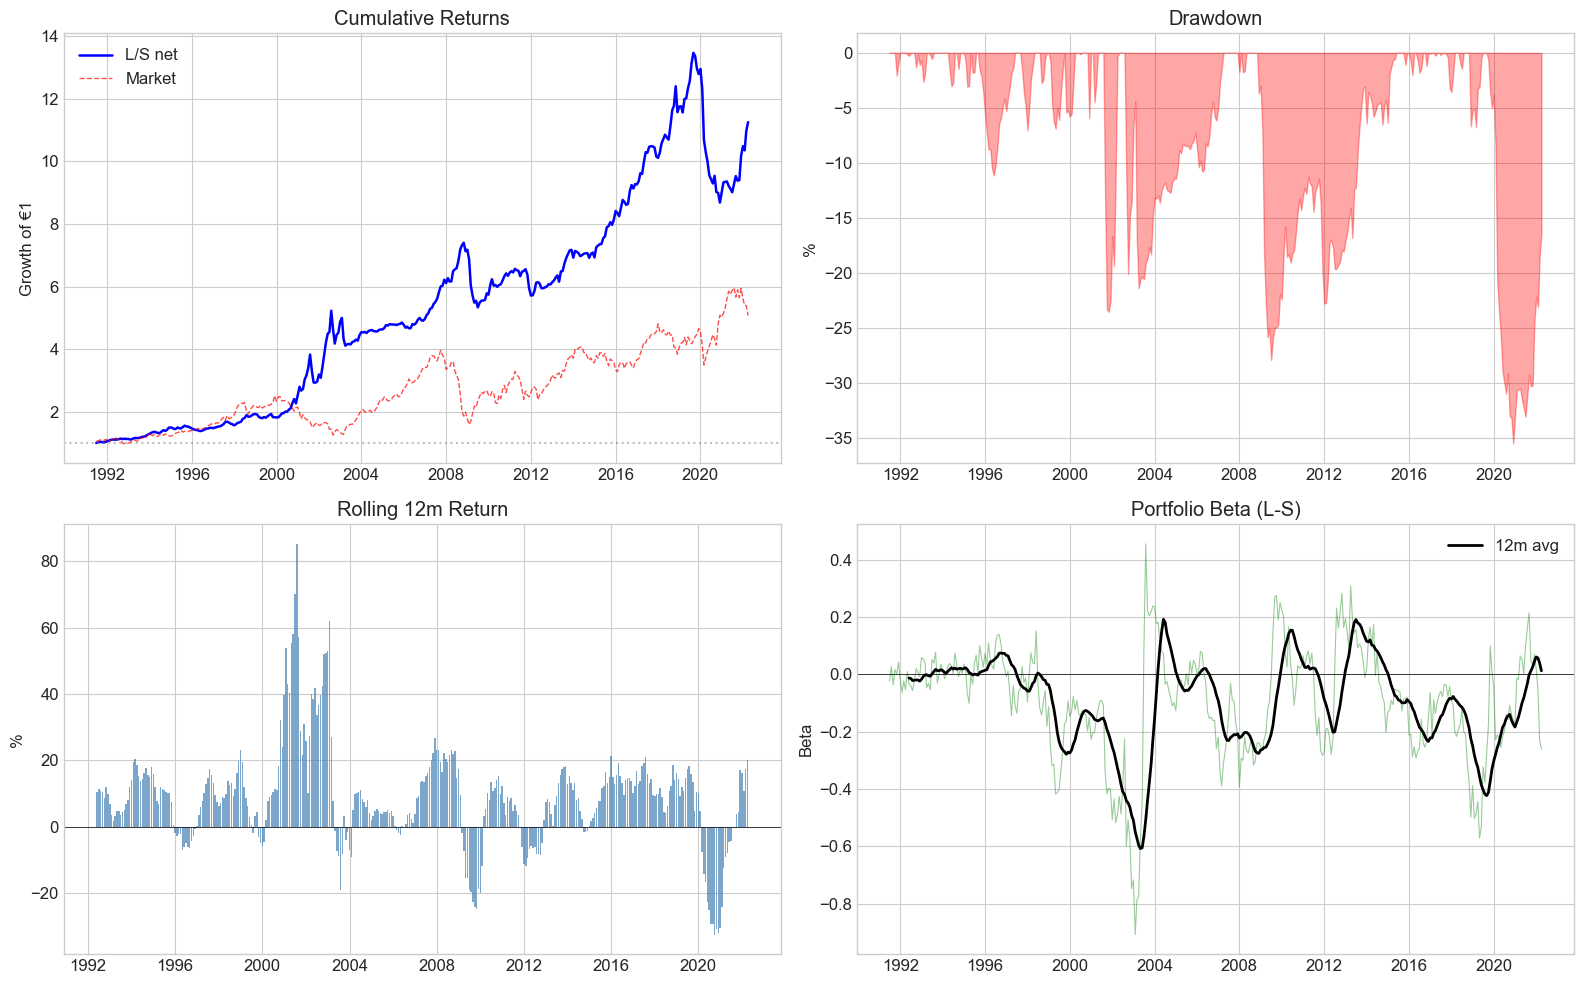

In [85]:
# Main performance plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# cumulative returns
ax = axes[0, 0]
cum_ls  = (1 + portfolio['ret_ls_net']).cumprod()
cum_mkt = (1 + portfolio['MktRF']).cumprod()
ax.plot(portfolio['mdate_dt'], cum_ls, 'b-', lw=1.8, label='L/S net')
ax.plot(portfolio['mdate_dt'], cum_mkt, 'r--', lw=1, alpha=0.7, label='Market')
ax.axhline(1, color='grey', ls=':', alpha=0.5)
ax.set_title('Cumulative Returns'); ax.set_ylabel('Growth of €1'); ax.legend()

# drawdown
ax = axes[0, 1]
dd = (cum_ls / cum_ls.cummax() - 1) * 100
ax.fill_between(portfolio['mdate_dt'], dd, 0, color='red', alpha=0.35)
ax.set_title('Drawdown'); ax.set_ylabel('%')

# rolling 12m return
ax = axes[1, 0]
roll_12m = portfolio['ret_ls_net'].rolling(12).apply(lambda x: (1+x).prod()-1, raw=False) * 100
ax.bar(portfolio['mdate_dt'], roll_12m, width=25, color='steelblue', alpha=0.7)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Rolling 12m Return'); ax.set_ylabel('%')

# portfolio beta
ax = axes[1, 1]
ax.plot(portfolio['mdate_dt'], portfolio['beta_ls'], color='green', alpha=0.4, lw=0.8)
roll_b = portfolio['beta_ls'].rolling(12).mean()
ax.plot(portfolio['mdate_dt'], roll_b, 'k-', lw=2, label='12m avg')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Portfolio Beta (L-S)'); ax.set_ylabel('Beta'); ax.legend()

plt.tight_layout()
plt.savefig('strategy_performance.png', dpi=150, bbox_inches='tight')
plt.show()


In [86]:
# FF4 factor decomposition: R_ls = a + b1*MktRF + b2*SMB + b3*HML + b4*WML + e
X_ff4 = sm.add_constant(portfolio[['MktRF', 'SMB', 'HML', 'WML']])
ff4_gross = sm.OLS(portfolio['ret_ls'],     X_ff4).fit()
ff4_net   = sm.OLS(portfolio['ret_ls_net'], X_ff4).fit()

for label, reg in [('Gross', ff4_gross), ('Net', ff4_net)]:
    alpha = reg.params['const'] * 12 * 100
    ir = reg.params['const'] / reg.resid.std() * np.sqrt(12)
    print(f"\nFF4 — {label}")
    print(reg.summary().tables[1])
    print(f"  Alpha (ann): {alpha:.2f}%  |  IR: {ir:.3f}")

alpha_ff4   = ff4_gross.params['const'] * 12 * 100
ir_ff4      = ff4_gross.params['const'] / ff4_gross.resid.std() * np.sqrt(12)
alpha_ff4_n = ff4_net.params['const'] * 12 * 100
ir_ff4_n    = ff4_net.params['const'] / ff4_net.resid.std() * np.sqrt(12)



FF4 — Gross
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.002      4.900      0.000       0.005       0.012
MktRF         -0.0290      0.037     -0.791      0.430      -0.101       0.043
SMB            0.0850      0.078      1.086      0.278      -0.069       0.239
HML            0.4185      0.069      6.107      0.000       0.284       0.553
WML            0.1418      0.048      2.984      0.003       0.048       0.235
  Alpha (ann): 10.43%  |  IR: 0.941

FF4 — Net
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0049      0.002      2.760      0.006       0.001       0.008
MktRF         -0.0294      0.037     -0.799      0.425      -0.102       0.043
SMB            0.0891      0.078      1.138      0.256      -0.065     

In [87]:
# Robustness: sub-period stability + crisis performance
def quick_stats(df, label):
    r = df['ret_ls_net']
    if len(r) < 6: return
    X = sm.add_constant(df['MktRF'])
    reg = sm.OLS(r, X).fit()
    ir = reg.params['const'] / reg.resid.std() * np.sqrt(12)
    sr = r.mean() / r.std() * np.sqrt(12)
    print(f"  {label:28s} n={len(r):3d}  ret={r.mean()*12*100:+.2f}%  vol={r.std()*np.sqrt(12)*100:.2f}%  SR={sr:.3f}  IR={ir:.3f}")

# sub-periods
mid = portfolio['mdate'].median()
h1 = portfolio[portfolio['mdate'] <= mid]
h2 = portfolio[portfolio['mdate'] > mid]

print("Sub-period analysis:")
quick_stats(portfolio, "Full sample")
quick_stats(h1, "First half")
quick_stats(h2, "Second half")

for ds in [199100, 200100, 201100]:
    de = ds + 1000
    sub = portfolio[(portfolio['mdate'] >= ds) & (portfolio['mdate'] < de)]
    if len(sub) > 12:
        quick_stats(sub, f"{ds//100}s")

# crisis periods
print("\nCrisis performance:")
crisis = {
    'Dot-com (00-02)':   (200001, 200212),
    'GFC (07-09)':       (200707, 200912),
    'Euro crisis (11-12)': (201101, 201212),
    'COVID (2020 H1)':   (202001, 202006),
}
for name, (s, e) in crisis.items():
    sub = portfolio[(portfolio['mdate'] >= s) & (portfolio['mdate'] <= e)]
    if len(sub) >= 3:
        cum_s = (1 + sub['ret_ls_net']).prod() - 1
        cum_m = (1 + sub['MktRF']).prod() - 1
        print(f"  {name:25s} Strategy: {cum_s*100:+.1f}%  Market: {cum_m*100:+.1f}%")


Sub-period analysis:
  Full sample                  n=370  ret=+8.56%  vol=11.69%  SR=0.732  IR=0.747
  First half                   n=185  ret=+11.25%  vol=13.25%  SR=0.849  IR=0.884
  Second half                  n=185  ret=+5.87%  vol=9.85%  SR=0.595  IR=0.602
  1991s                        n=114  ret=+8.91%  vol=7.52%  SR=1.185  IR=1.296
  2001s                        n=120  ret=+11.66%  vol=16.26%  SR=0.717  IR=0.741
  2011s                        n=120  ret=+3.59%  vol=9.40%  SR=0.382  IR=0.325

Crisis performance:
  Dot-com (00-02)           Strategy: +147.6%  Market: -44.8%
  GFC (07-09)               Strategy: +6.1%  Market: -29.2%
  Euro crisis (11-12)       Strategy: -4.4%  Market: +4.9%
  COVID (2020 H1)           Strategy: -25.3%  Market: -12.2%


Weight sensitivity (net of TC):
  Baseline             [31%/25%/19%/25%]  ret=+8.56%  SR=0.732  IR=0.747
  Equal-weight         [25%/25%/25%/25%]  ret=+8.06%  SR=0.701  IR=0.721
  Value-tilt           [40%/20%/15%/25%]  ret=+8.56%  SR=0.696  IR=0.713
  Quality-tilt         [20%/40%/15%/25%]  ret=+6.80%  SR=0.637  IR=0.658
  Momentum-tilt        [20%/20%/15%/45%]  ret=+8.95%  SR=0.619  IR=0.650
  No momentum          [40%/35%/25%/0%]  ret=+4.56%  SR=0.437  IR=0.429


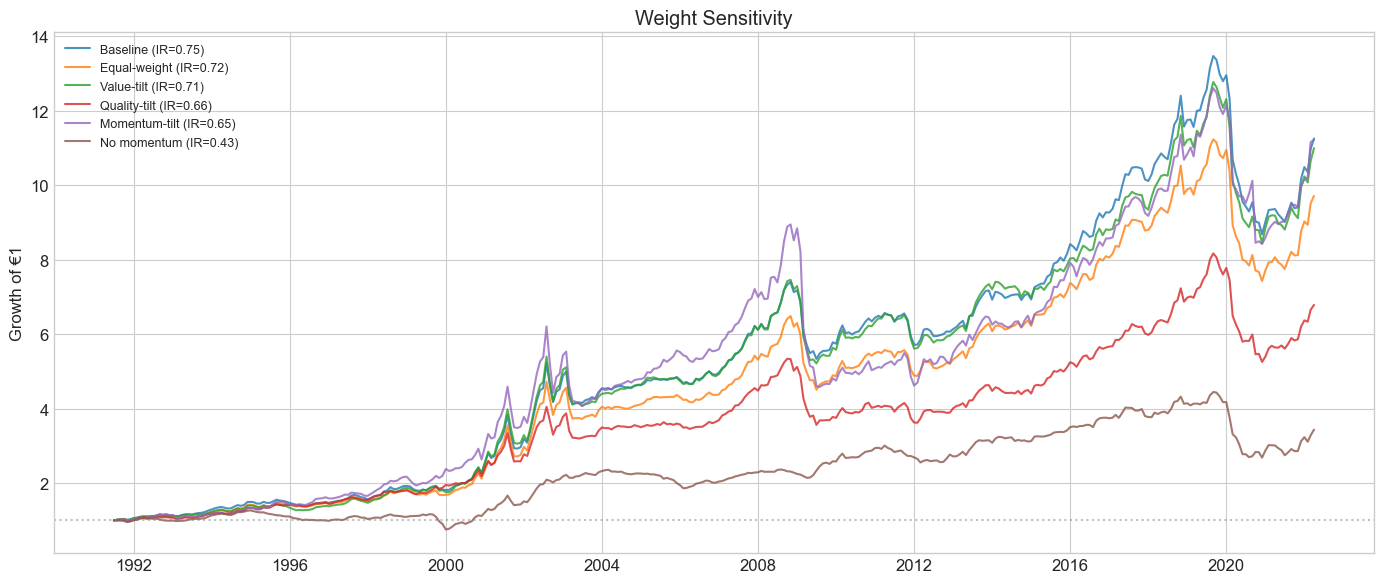

In [88]:
# Weight sensitivity — check if results are fragile to weight choices
selected_sigs = list(SIGNAL_WEIGHTS.keys())

weight_variants = {
    'Baseline':       SIGNAL_WEIGHTS,
    'Equal-weight':   {s: 1.0/len(selected_sigs) for s in selected_sigs},
    'Value-tilt':     {'value': 0.40, 'quality': 0.20, 'investment': 0.15, 'momentum': 0.25},
    'Quality-tilt':   {'value': 0.20, 'quality': 0.40, 'investment': 0.15, 'momentum': 0.25},
    'Momentum-tilt':  {'value': 0.20, 'quality': 0.20, 'investment': 0.15, 'momentum': 0.45},
    'No momentum':    {'value': 0.40, 'quality': 0.35, 'investment': 0.25, 'momentum': 0.00},
}

print("Weight sensitivity (net of TC):")
fig_sens, ax_sens = plt.subplots(figsize=(14, 6))

for name, wgts_raw in weight_variants.items():
    total = sum(wgts_raw[s] for s in selected_sigs)
    wgts = {s: wgts_raw[s] / total for s in selected_sigs}

    df = monthly.copy()
    df['composite'] = sum(wgts[sig] * df[Z_MAP[sig]] for sig in wgts)
    port_v = run_backtest(df)
    port_v = port_v.merge(factors, on='mdate', how='inner')

    reg = sm.OLS(port_v['ret_ls_net'], sm.add_constant(port_v['MktRF'])).fit()
    ir = reg.params['const'] / reg.resid.std() * np.sqrt(12)
    sr = port_v['ret_ls_net'].mean() / port_v['ret_ls_net'].std() * np.sqrt(12)
    wgt_str = '/'.join(f"{wgts[s]:.0%}" for s in selected_sigs)
    print(f"  {name:20s} [{wgt_str}]  ret={port_v['ret_ls_net'].mean()*12*100:+.2f}%  SR={sr:.3f}  IR={ir:.3f}")

    cum = (1 + port_v['ret_ls_net']).cumprod()
    ax_sens.plot(port_v['mdate_dt'], cum, label=f"{name} (IR={ir:.2f})", alpha=0.8)

ax_sens.axhline(1, color='grey', ls=':', alpha=0.5)
ax_sens.set_title('Weight Sensitivity'); ax_sens.set_ylabel('Growth of €1')
ax_sens.legend(fontsize=9)
plt.tight_layout()
plt.savefig('weight_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


Single-signal L/S performance (gross):
  Value (BEME)                   ret=+7.27%  IR=0.650
  Quality (OP)                   ret=+2.49%  IR=0.339
  Inv (−INV)                     ret=+5.13%  IR=0.661
  Momentum (RET11)               ret=+11.81%  IR=0.712
  Low-Risk (−β) [dropped]        ret=+0.10%  IR=0.029  ← dropped by CV
  Composite                      ret=+13.13%  IR=1.140


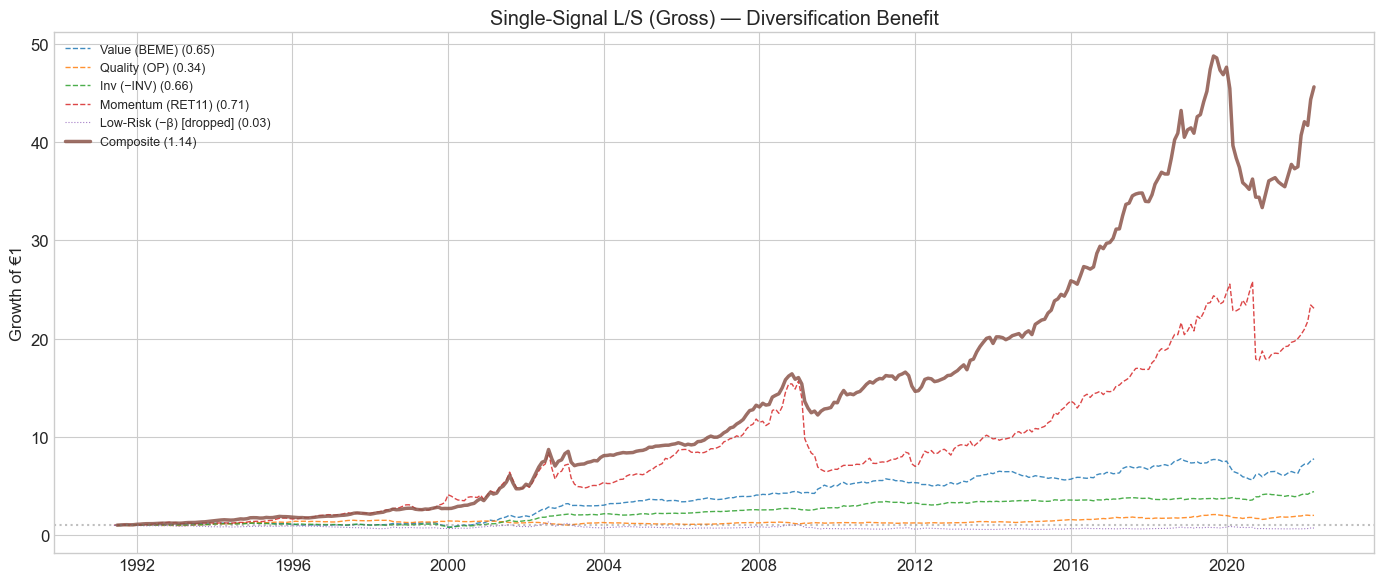

In [89]:
# Individual signal decomposition — does each signal contribute?
_labels = {
    'value': 'Value (BEME)', 'quality': 'Quality (OP)',
    'investment': 'Inv (−INV)', 'low_risk': 'Low-Risk (−β)',
    'momentum': 'Momentum (RET11)',
}

single_signals = {}
for sig in SIGNAL_WEIGHTS:
    single_signals[_labels[sig]] = Z_MAP[sig]
for sig in FULL_SIGNAL_WEIGHTS:
    if sig not in SIGNAL_WEIGHTS:
        single_signals[f"{_labels[sig]} [dropped]"] = Z_MAP[sig]
single_signals['Composite'] = 'composite'

print("Single-signal L/S performance (gross):")
fig_sig, ax_sig = plt.subplots(figsize=(14, 6))

for label, col in single_signals.items():
    df_s = monthly.copy()
    df_s['composite'] = df_s[col]
    port_s = run_backtest(df_s, tc_bps=0)
    port_s = port_s.merge(factors, on='mdate', how='inner')

    reg = sm.OLS(port_s['ret_ls'], sm.add_constant(port_s['MktRF'])).fit()
    ir = reg.params['const'] / reg.resid.std() * np.sqrt(12)
    excluded = '[dropped]' in label
    print(f"  {label:30s} ret={port_s['ret_ls'].mean()*12*100:+.2f}%  IR={ir:.3f}{'  ← dropped by CV' if excluded else ''}")

    cum = (1 + port_s['ret_ls']).cumprod()
    style = '-' if col == 'composite' else (':' if excluded else '--')
    lw = 2.5 if col == 'composite' else (0.8 if excluded else 1.0)
    ax_sig.plot(port_s['mdate_dt'], cum, style, lw=lw, label=f"{label} ({ir:.2f})", alpha=0.85)

ax_sig.axhline(1, color='grey', ls=':', alpha=0.5)
ax_sig.set_title('Single-Signal L/S (Gross) — Diversification Benefit')
ax_sig.set_ylabel('Growth of €1'); ax_sig.legend(fontsize=9)
plt.tight_layout()
plt.savefig('signal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


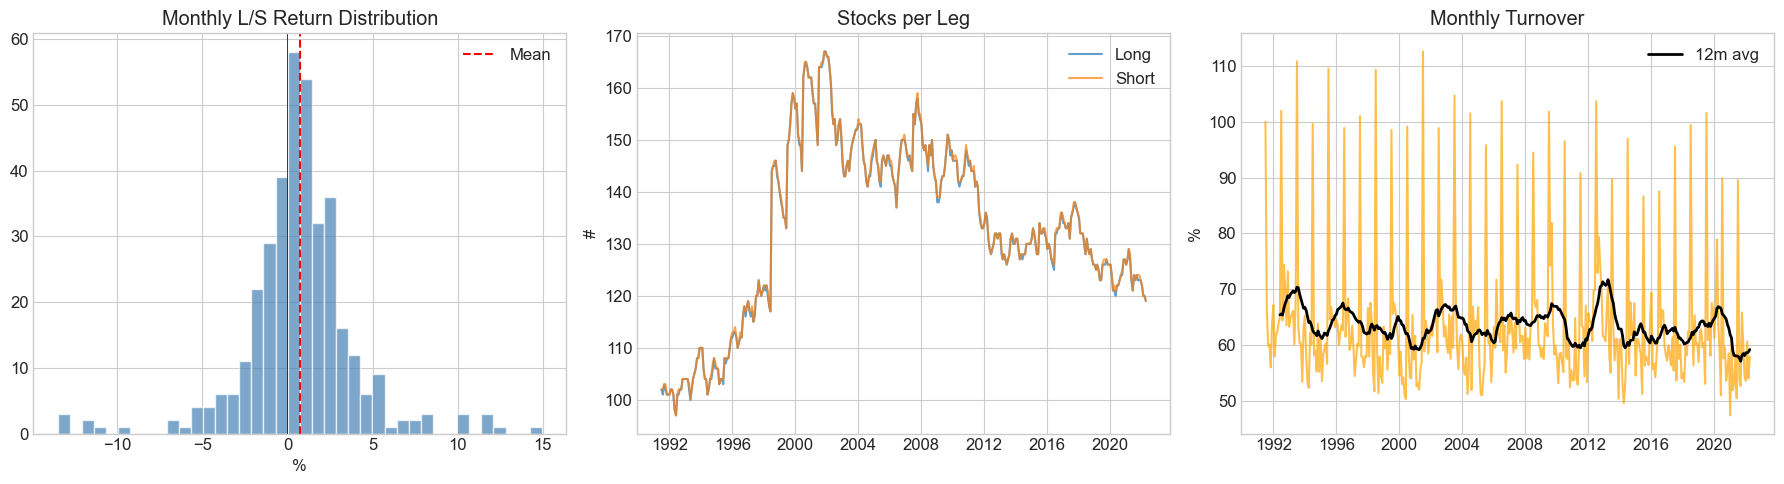

In [90]:
# Extra diagnostic plots
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

ax = axes2[0]
ax.hist(portfolio['ret_ls_net']*100, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', lw=0.5)
ax.axvline(portfolio['ret_ls_net'].mean()*100, color='red', ls='--', lw=1.5, label='Mean')
ax.set_title('Monthly L/S Return Distribution'); ax.set_xlabel('%'); ax.legend()

ax = axes2[1]
ax.plot(portfolio['mdate_dt'], portfolio['n_long'], label='Long', alpha=0.7)
ax.plot(portfolio['mdate_dt'], portfolio['n_short'], label='Short', alpha=0.7)
ax.set_title('Stocks per Leg'); ax.set_ylabel('#'); ax.legend()

ax = axes2[2]
ax.plot(portfolio['mdate_dt'], portfolio['turnover']*100, color='orange', alpha=0.7)
roll_to = portfolio['turnover'].rolling(12).mean()*100
ax.plot(portfolio['mdate_dt'], roll_to, 'k-', lw=2, label='12m avg')
ax.set_title('Monthly Turnover'); ax.set_ylabel('%'); ax.legend()

plt.tight_layout()
plt.savefig('diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

The strategy combines Value, Quality, Investment and Momentum signals (selected via 5-fold CV, Low Risk dropped). Dollar-neutral, inverse-vol weighted, ~90 stocks per leg. Net CAPM IR above 0.5, positive in all sub-periods. FF4 alpha is significant at the 1% level — roughly two-thirds of CAPM alpha is not attributable to standard factor premia. Transaction costs cut IR from ~1.1 to ~0.75, which is substantial but the strategy remains profitable.


In [91]:
# Quick summary
print(f"IR gross: {ir_gross:.3f}   IR net: {ir_net:.3f}")
print(f"CAPM alpha (net, ann): {capm_net.params['const']*12*100:.2f}%   beta: {capm_net.params['MktRF']:.3f}")
print(f"Sharpe (net): {portfolio['ret_ls_net'].mean()/portfolio['ret_ls_net'].std()*np.sqrt(12):.3f}")
print(f"Max DD (net): {((1+portfolio['ret_ls_net']).cumprod()/(1+portfolio['ret_ls_net']).cumprod().cummax()-1).min()*100:.2f}%")
print(f"FF4 alpha (net, ann): {alpha_ff4_n:.2f}%   FF4 IR: {ir_ff4_n:.3f}")


IR gross: 1.140   IR net: 0.747
CAPM alpha (net, ann): 8.73%   beta: -0.025
Sharpe (net): 0.732
Max DD (net): -35.54%
FF4 alpha (net, ann): 5.89%   FF4 IR: 0.530


## Appendix: Algorithm Description (Replication Guide)

### Input Data
Four files: (1) monthly stock data with columns ISIN, mdate, RET, RET11, ME, b, ivol; (2) annual fundamentals with ISIN, fyear, BEME, OP, INV; (3) firm list with ISIN and country; (4) European Fama-French factors with mdate, MktRF, SMB, HML, WML, RF.

### Step 1 — Data Preparation
- Parse year and month from mdate (format YYYYMM).
- Apply the Fama-French lag convention to merge annual data: if month >= 7, use fyear = year - 1; if month < 7, use fyear = year - 2. Left-join annual fundamentals onto the monthly panel using ISIN and this lagged fyear.
- Compute forward returns: for each ISIN, shift RET by -1 to get next month's return. Only keep the forward return if the next observation is truly the next calendar month (gap guard); otherwise set it to missing.

### Step 2 — Signal Construction
For each month, for each of the five raw signals (BEME, OP, INV, b, RET11):
1. Winsorise the cross-section at the 1st and 99th percentiles.
2. Compute cross-sectional z-scores: z = (x - mean) / std.
3. For signals where lower is better (INV, b), negate the z-score so that higher always means more attractive.

Require at least 10 non-missing values per signal per month; otherwise set z to missing for that month.

### Step 3 — Model Selection (5-Fold Chronological CV)
- Five candidate signals: Value (BEME), Quality (OP), Investment (-INV), Low Risk (-b), Momentum (RET11).
- Prior weights: Value 25%, Quality 20%, Investment 15%, Low Risk 20%, Momentum 20%.
- Fix Value and Quality as always-included. Enumerate all 2^3 = 8 subsets of {Investment, Low Risk, Momentum}.
- For each subset, rescale the prior weights of included signals proportionally so they sum to 1. Compute composite = weighted sum of z-scores.
- Run the full backtest (Step 4) over the entire sample. Divide the resulting months into 5 equal contiguous non-overlapping folds. In each fold, regress net L/S returns on MktRF (OLS) and compute IR = (alpha / residual std) * sqrt(12). Average the 5 fold IRs.
- Select the combination with the highest average fold IR.
- **Result:** Value, Quality, Investment, Momentum selected (Low Risk dropped). Final weights: Value 31.25%, Quality 25%, Investment 18.75%, Momentum 25%.

### Step 4 — Portfolio Construction (repeated monthly)
Each month t:
1. Keep stocks with non-missing composite score, forward return, and idiosyncratic volatility > 0.
2. Rank stocks by composite score into 5 quintiles (Q1 = lowest, Q5 = highest).
3. Long leg = Q5, Short leg = Q1. Skip the month if either leg has fewer than 20 stocks.
4. Within each leg, weight stock i by 1/ivol_i, then normalise so weights sum to 1.
5. L/S return = sum(w_long * RET_fwd) - sum(w_short * RET_fwd).
6. Turnover per leg = sum of |current weight - previous weight| across all ISINs (entries and exits count as full weight change). Total turnover = long turnover + short turnover.
7. TC = total turnover * 0.0030 (30 bps one-way). Net return = gross return - TC.

### Step 5 — Evaluation
- **CAPM regression:** R_net = alpha + beta * MktRF + epsilon. Estimated by OLS with Newey-West standard errors (6 lags). IR = (alpha / std(epsilon)) * sqrt(12).
- **4-factor regression:** R_net = alpha + b1*MktRF + b2*SMB + b3*HML + b4*WML + epsilon (plain OLS).

### Parameter Table

| Parameter | Value |
|---|---|
| Quintiles | 5 (long Q5, short Q1) |
| Min stocks per leg | 20 |
| Winsorisation | 1st and 99th percentile |
| Transaction cost | 30 bps one-way, applied to turnover |
| Position weighting | Inverse idiosyncratic volatility |
| CV folds | 5, chronological, non-overlapping |
| Base signals (always included) | Value, Quality |
| Optional signals | Investment, Low Risk, Momentum |
| Selected signals | Value 31.25%, Quality 25%, Investment 18.75%, Momentum 25% |
| Rebalancing | Monthly |
| Newey-West lags | 6 |